In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("D:/Machine_Learning/Datasets/monthly-milk-production-pounds-p.csv", index_col=0)
df

,Milk
Month,
1962-01,589
1962-02,561
1962-03,640
1962-04,656
1962-05,727
...,...
1975-08,858
1975-09,817
1975-10,827


In [24]:
df.index = pd.to_datetime(df.index).to_period('M')


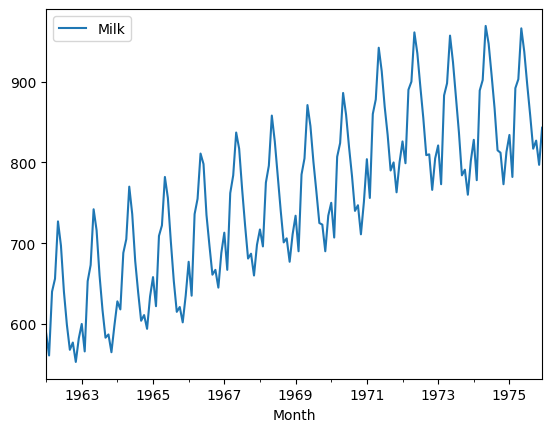

In [25]:
df.plot()
plt.show()

In [12]:
downsampled = df.resample("Q").sum()
downsampled.index.rename('Quarter', inplace=True)
downsampled

,Milk
Quarter,
1962Q1,1790
1962Q2,2080
1962Q3,1807
1962Q4,1712
1963Q1,1819
1963Q2,2131
1963Q3,1860
1963Q4,1750
1964Q1,1934


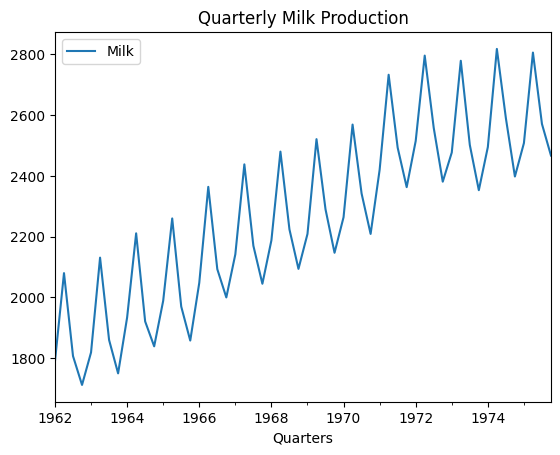

In [13]:
downsampled.plot()
plt.title("Quarterly Milk Production")
plt.xlabel("Quarters")
plt.show()

## Decomposition

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

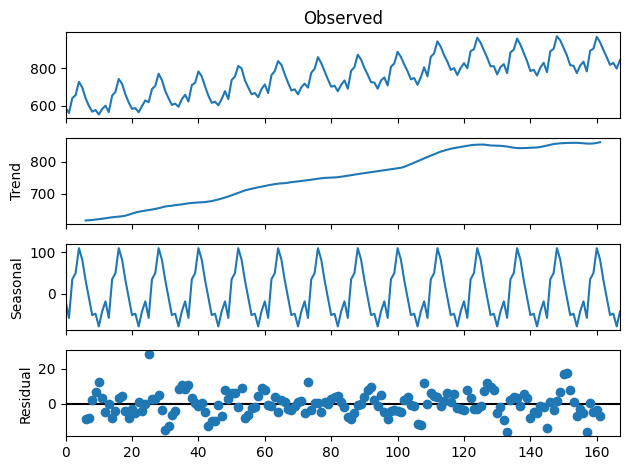

In [17]:
result = seasonal_decompose(df['Milk'].values, model='additive', period=12)
result.plot()
plt.show()     #Residual = Error (it should not have any pattern)

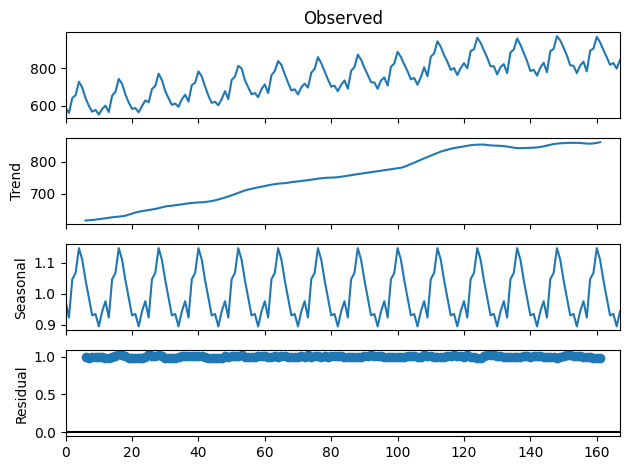

In [18]:
result = seasonal_decompose(df['Milk'].values, model='multiplicative', period=12)
result.plot()
plt.show()

## Centered Moving Average

In [20]:
from ipywidgets import interact

In [30]:
def CMA(span):
    fcast = df['Milk'].rolling(span, center=True).mean()
    plt.plot( df['Milk'].values, label='Data')
    plt.plot(fcast.values, label = 'Centered Rolling Mean')
    plt.legend(loc='best')
    plt.show()
interact(CMA, span = (1,6)) 

interactive(children=(IntSlider(value=3, description='span', max=6, min=1), Output()), _dom_classes=('widget-i…

<function __main__.CMA(span)>